<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634  

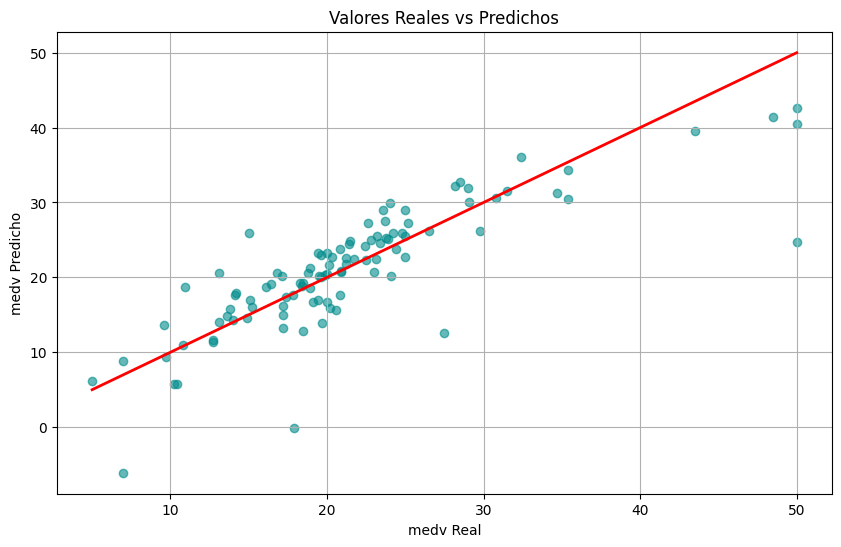

23.19731083453846


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

print(df.info())
print(df.describe())

X = df.drop("medv", axis=1)
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_train, y_train)

X_train_const = sm.add_constant(X_train)
modelo_ols = sm.OLS(y_train, X_train_const).fit()

print(modelo_ols.summary())

no_significativas = modelo_ols.pvalues[modelo_ols.pvalues > 0.05]
print(no_significativas)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_df)

corr_matrix = X.corr()
autovalores, _ = np.linalg.eig(corr_matrix)
print(autovalores)

y_pred = modelo_sklearn.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='darkcyan', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Valores Reales vs Predichos')
plt.xlabel('medv Real')
plt.ylabel('medv Predicho')
plt.grid(True)
plt.show()

medianas_variables = X.median().values.reshape(1, -1)
prediccion_final = modelo_sklearn.predict(pd.DataFrame(medianas_variables, columns=X.columns))

print(prediccion_final[0])